# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**: Thales Leonardo Euler Vieira de Sousa &nbsp;&nbsp; **RA**: 822881

**Nome**: Enrico Augusto Pagani da Silva &nbsp;&nbsp; **RA**: 822888

## Configuração do ambiente

Carregamos os scripts auxiliares (em `scripts/`) e habilitamos o *autoreload* para refletir alterações feitas nos arquivos `.py` sem reiniciar o kernel.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts import preprocessamento as prep
from scripts import analise_exploratoria as eda
from scripts import experimentos as exp
from scripts import analise_resultados as res

# Caminhos da base (VICTOR / STF). Ajuste se necessário (ex.: Kaggle).
CAMINHO_TREINO = "train.csv"
CAMINHO_TESTE = "test.csv"

---
### Análise exploratória

Nesta seção, deve ser feita a leitura da base de dados e todas as análises necessárias para interpretar e analisar os dados, tais como:
* Significado de cada atributo
* Medidas descritivas
* Gráficos

A base possui três atributos: `Id` (identificador do documento), `Body` (texto extraído, muitas vezes por OCR) e `Category` (classe). Há **cinco classes válidas** (0-Acórdão, 1-ARE, 2-Despacho, 3-RE, 4-Sentença) e ainda um rótulo **`-1`**, que corresponde às páginas **não rotuladas** do corpus VICTOR.

In [2]:
# Leitura com correção automática do encoding (mojibake UTF-8/Latin-1).
df_treino = prep.carregar_dados(CAMINHO_TREINO)
eda.resumo_geral(df_treino)

Numero de amostras : 22680
Numero de colunas  : 3
Colunas            : ['Id', 'Body', 'Category']
Valores ausentes   :
Id          0
Body        0
Category    0
dtype: int64

Distribuicao de classes:
  Nao rotulado (-1)      :   2268 (10.00%)
  0 - Acordao            :    665 ( 2.93%)
  1 - ARE                :   3529 (15.56%)
  2 - Despacho           :    439 ( 1.94%)
  3 - RE                 :  12876 (56.77%)
  4 - Sentenca           :   2903 (12.80%)


c:\Users\Enrico\Documents\Estudos_Facul\PLN\822881-822888-PROJ-PLN\IMPLEMENTACAO\scripts\analise_exploratoria.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rotulos, y=dist.values, ax=ax, palette="viridis")


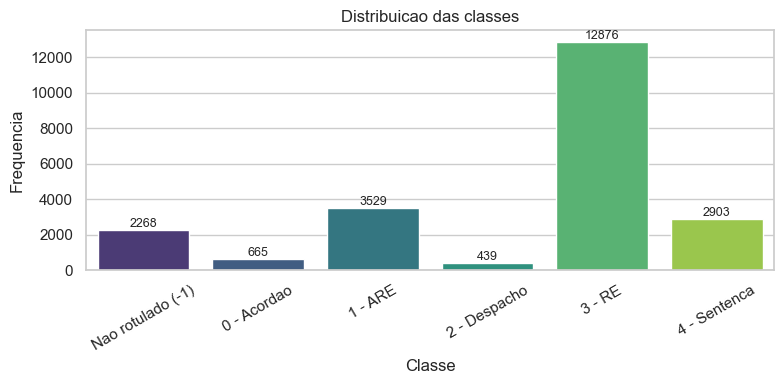

In [3]:
# Distribuição das classes: forte desbalanceamento (classe 3-RE domina).
eda.plotar_distribuicao_classes(df_treino)
plt.tight_layout(); plt.show()

       n_caracteres      n_tokens
count  22680.000000  22680.000000
mean    1696.527822    216.373280
std      721.834523     93.064418
min        4.000000      1.000000
25%     1247.000000    159.000000
50%     1650.000000    209.000000
75%     2101.000000    268.000000
max     6603.000000    844.000000


c:\Users\Enrico\Documents\Estudos_Facul\PLN\822881-822888-PROJ-PLN\IMPLEMENTACAO\scripts\analise_exploratoria.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="classe", y=coluna_tokens, ax=ax, showfliers=False,


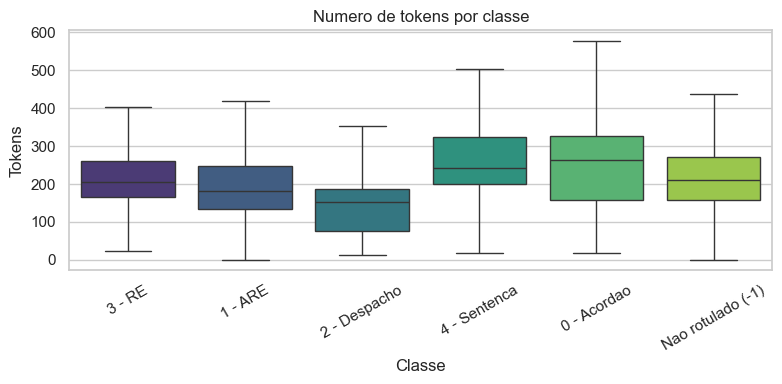

In [4]:
# Estatísticas de tamanho dos documentos (caracteres e tokens).
df_tam = eda.estatisticas_tamanho(df_treino)
eda.plotar_tamanho_por_classe(df_tam)
plt.tight_layout(); plt.show()

---
### Pré-processamento

Nesta seção, as funções da etapa de pré-processamento dos dados devem ser implementadas e aplicadas (se necessário).

Etapas aplicadas (ver `scripts/preprocessamento.py`):
1. **Correção de encoding** (mojibake) e remoção do invlucro `{"..."}`;
2. **Limpeza** de ruído de OCR, números e pontuação; normalização de marcadores `ARTIGO_xxx`;
3. **Minusculização** e remoção de acentos;
4. **Remoção de stopwords** do português (NLTK);
5. (Opcional) **Stemming** com RSLP.

As amostras **não rotuladas (`-1`)** são removidas do treino supervisionado.

In [5]:
# Remove não rotulados e aplica o pré-processamento textual.
df_treino = prep.filtrar_rotulados(df_treino)
df_treino = prep.preprocessar_dataframe(df_treino, usar_stopwords=True, usar_stemming=False)

print("Amostras rotuladas:", len(df_treino))
print("\nAntes :", df_treino['Body'].iloc[0][:150])
print("\nDepois:", df_treino['texto_limpo'].iloc[0][:150])

Amostras rotuladas: 20412

Antes : {"conclusão diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituição federal será admitido 

Depois: conclusao diante exposto recorrente espera confia recurso ora arrazoado interposto fulcro artigo_102 iii constituicao federal admitido conhecido provi


[0 - Acordao]
  recurso, federal, parte, sentenca, turma, beneficios, sobre, valor, relator, juiz, pagamento, lei

[1 - ARE]
  recurso, federal, decisao, extraordinario, geral, agravo, direito, tribunal, constitucional, constituicao, presente, turma

[2 - Despacho]
  recurso, agravo, extraordinario, decisao, federal, recursal, turma, tribunal, autos, desta, processo, interposto

[3 - RE]
  federal, geral, fazenda, lei, procuradoria, nacional, recurso, uniao, direito, constitucional, constituicao, principio

[4 - Sentenca]
  lei, contribuicao, federal, servidores, parte, sobre, valor, beneficios, data, desempenho, gdpst, partir



c:\Users\Enrico\Documents\Estudos_Facul\PLN\822881-822888-PROJ-PLN\IMPLEMENTACAO\scripts\analise_exploratoria.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freqs, y=palavras, ax=ax, palette="mako")


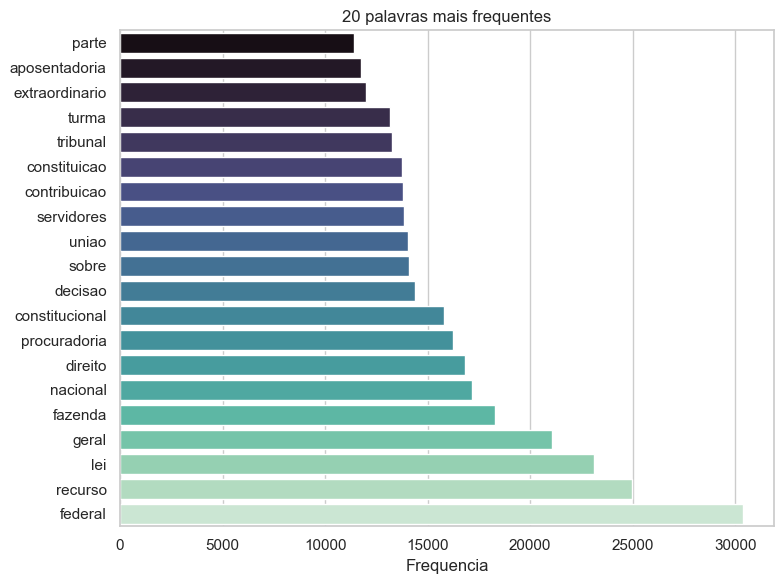

In [6]:
# Vocabulário mais frequente por classe (insight para engenharia de atributos).
eda.palavras_frequentes_por_classe(df_treino, n=12)
eda.plotar_nuvem_frequencia(df_treino, n=20)
plt.tight_layout(); plt.show()

---
### Experimento

Nesta seção, o experimento deve ser conduzido, utilizando os protocolos experimentais padrões e testando diferentes modelos.

**Representação:** TF-IDF combinando n-gramas de **palavra** (1-2) e de **caractere** (3-5) — esta última é robusta a erros de OCR.

**Modelos clássicos:** Complement Naive Bayes, Regressão Logística e SVM Linear (todos com tratamento de desbalanceamento via `class_weight`).

**Protocolo:** validação cruzada estratificada (5 folds), métrica **F1-weighted** (métrica oficial da competição; reporta-se também a F1-macro).

In [ ]:
# Busca em grade (Grid Search) sobre o parâmetro C do LinearSVC.
# Confirma C=2.0 como valor ótimo (F1-weighted, 5-fold CV).
X = df_treino[["texto_limpo"]]
y = df_treino["Category"]
melhor_C = exp.ajustar_hiperparametros(X, y, n_splits=5)

In [ ]:
X = df_treino[["texto_limpo"]]
y = df_treino["Category"]

# Compara os modelos clássicos por validação cruzada (pode levar alguns minutos).
tabela_cv, predicoes_oof = exp.comparar_modelos(X, y, n_splits=5)
tabela_cv

NaiveBayes   F1-weighted (CV) = 0.8390   F1-macro = 0.7948
LogReg       F1-weighted (CV) = 0.9209   F1-macro = 0.9044
LinearSVM    F1-weighted (CV) = 0.9306   F1-macro = 0.9107


,modelo,f1_weighted,f1_macro
0,LinearSVM,0.930582,0.910691
1,LogReg,0.920928,0.904439
2,NaiveBayes,0.839020,0.794758


---
### Análise dos Resultados

Nesta seção, os resultados devem ser exibidos através de tabelas e gráficos, comparados e profundamente analisados.

Usamos as predições *out-of-fold* (cada amostra prevista quando estava no fold de teste) para um diagnóstico honesto: relatório por classe, matriz de confusão e comparação de F1 por classe entre os modelos.

/home/thaleseuler/Documentos/VSC/PLN/template-implementacao/./scripts/analise_resultados.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tabela, x="modelo", y=coluna, ax=ax, palette="rocket")


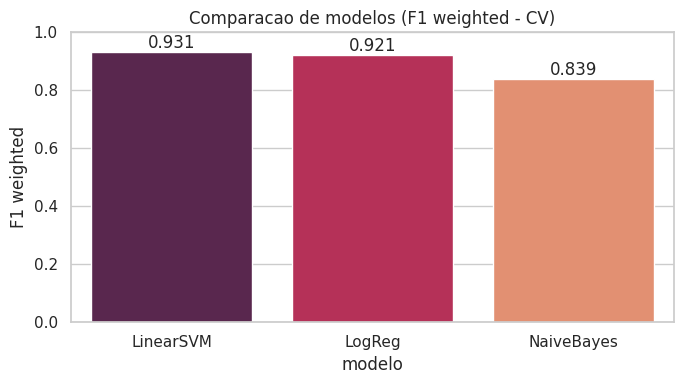

In [ ]:
# Comparação geral dos modelos (F1-weighted).
res.plotar_comparacao_modelos(tabela_cv)
plt.tight_layout(); plt.show()

Melhor modelo: LinearSVM 

              precision    recall  f1-score   support

     Acordao     0.9305    0.8662    0.8972       665
         ARE     0.8748    0.8118    0.8422      3529
    Despacho     0.9500    0.8656    0.9058       439
          RE     0.9386    0.9647    0.9515     12876
    Sentenca     0.9601    0.9535    0.9568      2903

    accuracy                         0.9314     20412
   macro avg     0.9308    0.8924    0.9107     20412
weighted avg     0.9306    0.9314    0.9306     20412

F1 macro    : 0.9107
F1 weighted : 0.9306


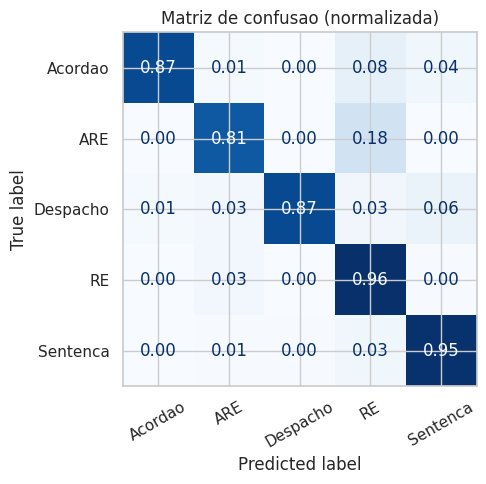

In [ ]:
# Diagnóstico detalhado do melhor modelo.
melhor = tabela_cv.iloc[0]["modelo"]
print("Melhor modelo:", melhor, "\n")
res.relatorio_classificacao(y, predicoes_oof[melhor])
res.plotar_matriz_confusao(y, predicoes_oof[melhor])
plt.tight_layout(); plt.show()

In [ ]:
# F1 por classe para todos os modelos.
res.comparar_f1_por_classe(predicoes_oof, y)

,Acordao,ARE,Despacho,RE,Sentenca,macro
modelo,,,,,,
NaiveBayes,0.7950,0.6777,0.7688,0.8863,0.8460,0.7948
LogReg,0.8971,0.8258,0.9047,0.9415,0.9531,0.9044
LinearSVM,0.8972,0.8422,0.9058,0.9515,0.9568,0.9107


#### Treino final e geração da submissão

Treinamos o melhor modelo em **todo** o conjunto rotulado e geramos a submissão no formato `Id,Category` exigido pelo Kaggle.

In [ ]:
# Treina o melhor modelo clássico em todo o conjunto rotulado e gera a submissão.
pipe_final = exp.montar_pipeline(exp.construir_modelos()[melhor])
pipe_final = exp.treinar_final(pipe_final, X, y)

df_teste = prep.carregar_dados(CAMINHO_TESTE)
df_teste = prep.preprocessar_dataframe(df_teste, usar_stopwords=True, usar_stemming=False)

submissao = exp.gerar_submissao(pipe_final, df_teste, "submission.csv")

# Salva também as probabilidades do SVM no teste (entram no ensemble final).
pipe_svm = exp.treinar_final(
    exp.montar_pipeline(exp.construir_modelos()["LinearSVM"]), X, y)
probs_svm = pipe_svm.predict_proba(df_teste[["texto_limpo"]])
pd.DataFrame(probs_svm, columns=[f"p{c}" for c in range(5)]) \
    .assign(Id=df_teste["Id"].values).to_csv("svm_probs_test.csv", index=False)
print("svm_probs_test.csv salvo (para o ensemble).")
submissao.head()

Submissao salva em 'submission.csv' (2521 linhas).
svm_probs_test.csv salvo (para o ensemble).


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


---
### Modelos profundos (Transformers) e ensemble final

A solução final combina o modelo clássico acima com o *fine-tuning* de dois modelos de linguagem em português — **BERTimbau** (geral) e **LegalBERT-pt** (jurídico) — implementados em `scripts/bertimbau_kaggle.py` (treino simples) e `scripts/bert_kfold_kaggle.py` (validação cruzada *k-fold*, usada na versão final).

Esses scripts **requerem GPU**: detectam o ambiente automaticamente (lendo a base do diretório local e usando CUDA se disponível, ou os caminhos do Kaggle) e geram, além do `submission.csv`, os arquivos de probabilidades por classe (`{modelo}_probs_test.csv`). A célula abaixo executa o BERTimbau **somente se houver GPU** — em CPU o treinamento é inviável (várias horas), então a etapa é ignorada com uma mensagem orientando como reproduzi-la.

In [ ]:
# Fine-tuning do BERTimbau a partir da MESMA base (requer GPU/CUDA).
# Gera submission.csv + bertimbau_probs_test.csv + bertimbau_val_probs.csv.
# Para a versão final (k-fold), use scripts/bert_kfold_kaggle.py de modo análogo.
try:
    import torch
    if torch.cuda.is_available():
        from scripts import bertimbau_kaggle as bert
        bert.main()
    else:
        print("GPU (CUDA) não disponível -> etapa do BERTimbau ignorada nesta execução.")
        print("Para reproduzi-la, execute em ambiente com GPU (local ou Kaggle).")
except ImportError as e:
    print("Dependências de deep learning ausentes (torch/transformers):", e)

Dependências de deep learning ausentes (torch/transformers): No module named 'torch'


In [ ]:
# Ensemble final (solução submetida): média ponderada das probabilidades por
# classe de SVM, BERTimbau e LegalBERT-pt (pesos 0.45/0.25/0.30, ajustados por
# validação cruzada). Requer os arquivos de probabilidade gerados acima e pelos
# scripts dos Transformers; caso ausentes, a célula apenas avisa.
import os

arqs = {"svm": "svm_probs_test.csv",
        "bert": "bertimbau_probs_test.csv",
        "legal": "legalbert_probs_test.csv"}

if all(os.path.exists(a) for a in arqs.values()):
    pcols = [f"p{c}" for c in range(5)]
    svm = pd.read_csv(arqs["svm"])
    bt = pd.read_csv(arqs["bert"])
    lb = pd.read_csv(arqs["legal"])
    m = svm.merge(bt, on="Id", suffixes=("_svm", "_bt")).merge(lb, on="Id")
    P = (0.45 * m[[f"{c}_svm" for c in pcols]].values
         + 0.25 * m[[f"{c}_bt" for c in pcols]].values
         + 0.30 * m[pcols].values)
    pd.DataFrame({"Id": m["Id"], "Category": P.argmax(1)}) \
        .to_csv("submission_ensemble.csv", index=False)
    print("submission_ensemble.csv gerado (ensemble 0.45/0.25/0.30).")
else:
    faltando = [a for a in arqs.values() if not os.path.exists(a)]
    print("Ensemble não gerado; arquivos de probabilidade ausentes:", faltando)
    print("Rode os scripts dos Transformers (com GPU) para produzi-los.")

submission_ensemble.csv gerado (ensemble 0.45/0.25/0.30).


In [ ]:
# Ensemble alternativo: 55/22.5/22.5 (mais SVM, mais robusto a OCR)
arqs = {"svm": "svm_probs_test.csv",
        "bert": "bertimbau_probs_test.csv",
        "legal": "legalbert_probs_test.csv"}

if all(os.path.exists(a) for a in arqs.values()):
    pcols = [f"p{c}" for c in range(5)]
    svm = pd.read_csv(arqs["svm"])
    bt = pd.read_csv(arqs["bert"])
    lb = pd.read_csv(arqs["legal"])
    m = svm.merge(bt, on="Id", suffixes=("_svm", "_bt")).merge(lb, on="Id")
    P = (0.55 * m[[f"{c}_svm" for c in pcols]].values
        + 0.225 * m[[f"{c}_bt" for c in pcols]].values
        + 0.225 * m[pcols].values)
    pd.DataFrame({"Id": m["Id"], "Category": P.argmax(1)}) \
        .to_csv("submission_3way_svm55_split.csv", index=False)
    print("submission_3way_svm55_split.csv gerado (ensemble 0.55/0.225/0.225).")
else:
    faltando = [a for a in arqs.values() if not os.path.exists(a)]
    print("Ensemble não gerado; arquivos de probabilidade ausentes:", faltando)